# Checking normalization data

In [3]:
%%time
%run 'load-data.ipynb'

Building DAG of jobs...
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_13563002_magdown_rs.root', 'root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_13563002_magup_rs.root']
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_23903000_magdown_rs.root', 'root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_23903000_magup_rs.root']
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/

In [4]:
len(mcsignal)

25843

In [5]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (15,6)

In [6]:
def mygroupby(d, groupbycols):
    """ Utility to group by a column and show relative statistics """
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

## Some statistics

In [18]:
mcbysep = mcsignal.query('B_Y_SEP < -4.5')

In [19]:
len(mcbysep.query('bdt_dc > 0.75'))

5318

In [32]:
total_generated = 4292418.0
print(f"epsilon1 = {len(mcbysep.query('bdt_dc > 0.75'))/total_generated}")
print(f"epsilon2 = {len(mcbysep.query('bdt_dc > 0.35'))/total_generated}")
print(f"epsilon3 = {len(mcbysep.query('bdt_dc > 0.5'))/total_generated}")

epsilon1 = 0.0012389287343404114
epsilon2 = 0.002330621109127769
epsilon3 = 0.0020913620248540566


In [21]:
len(mcbysep.query('bdt_dc > 0.35'))

10004

In [20]:
len(mcbysep.query('bdt_dc > 0.5'))

8977

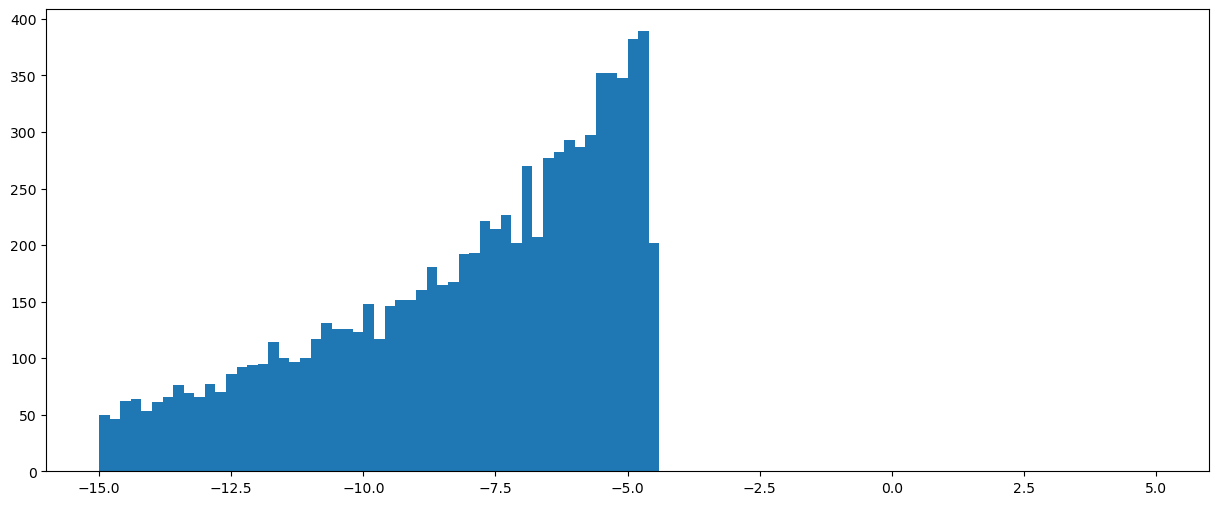

In [22]:
plt.hist(mcbysep['B_Y_SEP'], bins=100, range=[-15, 5]);

In [29]:
mygroupby(mcbysep.query('bdt_dc > 0.75'), 'key')

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_displaced_fromBs_fromTau,4801,90.278300,90.278300
1,Xc_background,245,4.606995,94.885295
2,Xc_signal_Ypis_nomatch_Prompt,224,4.212110,99.097405
3,Xc_signal_Ypis_diffVertex_signal,43,0.808575,99.905980
4,Xc_signal_Ypis_B_vertex_fromBs,2,0.037608,99.943588
5,Xc_signal_Ypis_diffVertex_SomeFromPV,1,0.018804,99.962392
6,Xc_signal_Ypis_nomatch_charmStrange,1,0.018804,99.981196
7,Xc_signal_Ypis_nomatch_doubleCharm,1,0.018804,100.000000


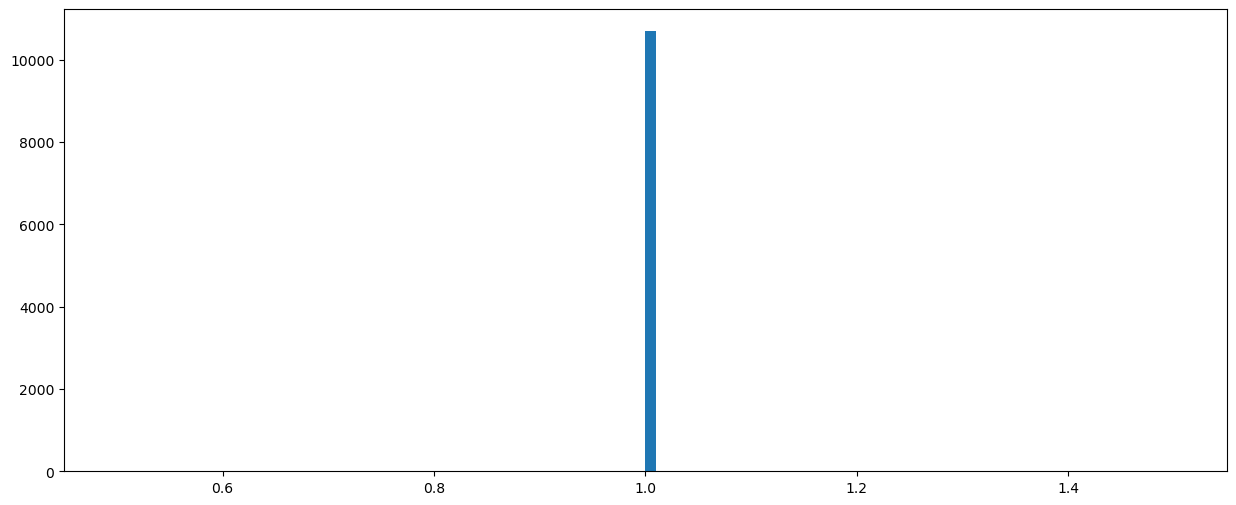

In [35]:
plt.hist(mcbysep['Xc_Selection'], bins=100);

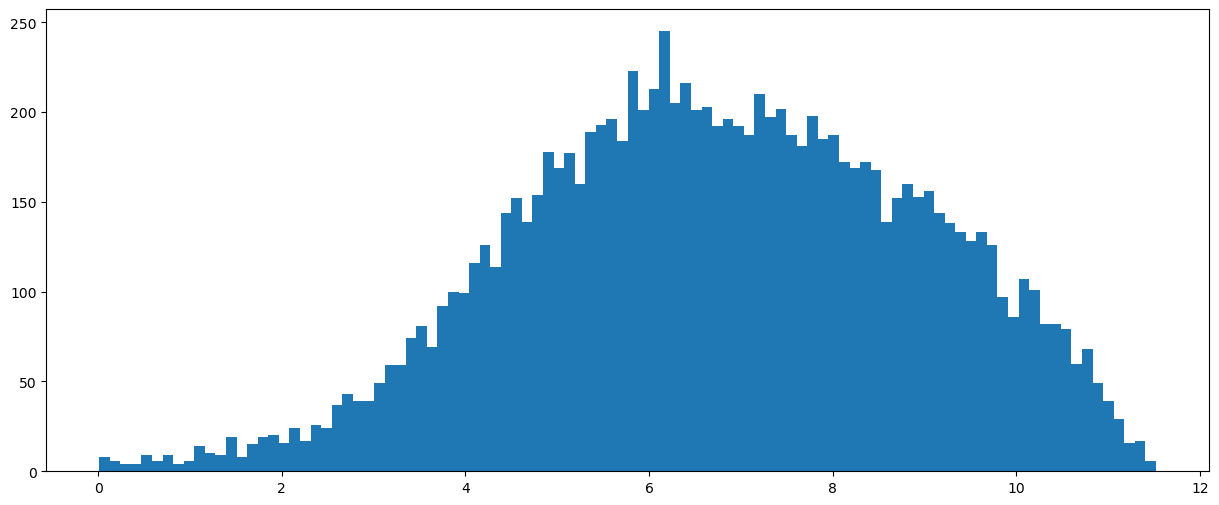

In [37]:
plt.hist(mcbysep['q2_2'], bins=100);

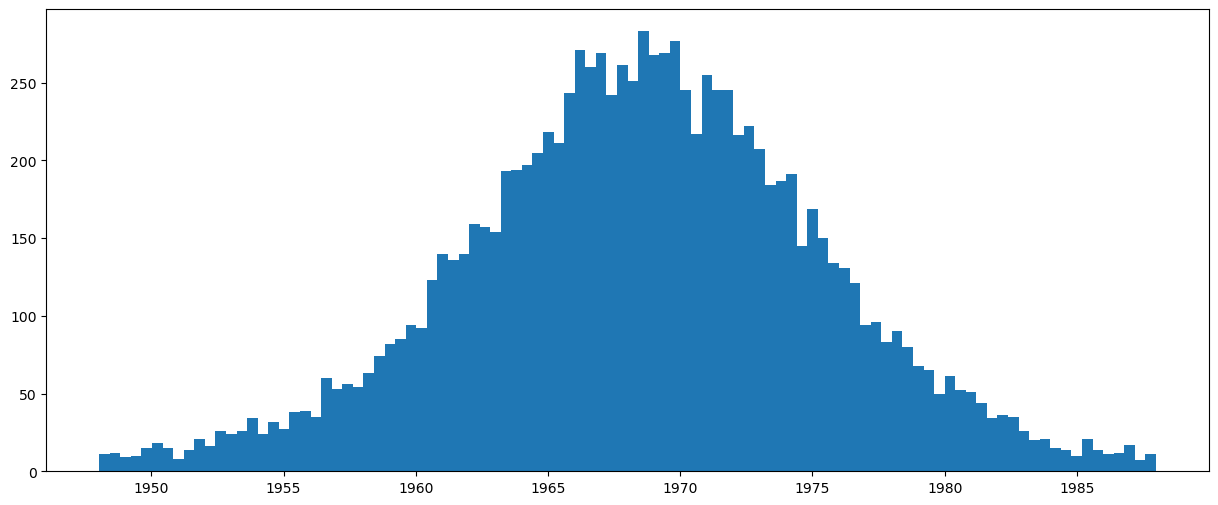

In [40]:
plt.hist(mcbysep['Xc_MM'], bins=100);

In [38]:
mcbysep.columns

Index(['BDT_3pi', 'BDT_Bs', 'BDT_Ds', 'BDT_Iso', 'B_BPVVDR', 'B_ENDVERTEX_X',
       'B_ENDVERTEX_Y', 'B_ENDVERTEX_Z', 'B_ENDVERTEX_ZERR', 'B_ETA', 'B_M',
       'B_MM', 'B_P', 'B_PT', 'B_Y_SEP', 'B_correctedMass', 'B_pT_Bdir',
       'PBsn', 'PBv', 'PBvn', 'Xc_BKGCAT', 'Xc_ENDVERTEX_CHI2',
       'Xc_ENDVERTEX_X', 'Xc_ENDVERTEX_Y', 'Xc_ENDVERTEX_Z', 'Xc_ETA',
       'Xc_FD_ORIVX', 'Xc_FD_OWNPV', 'Xc_M', 'Xc_MM', 'Xc_PT', 'Xc_Selection',
       'Xc_signal_Ypis_displaced_fromBs_fromTau', 'Y_0_20_cc_PZ',
       'Y_0_20_cc_mult', 'Y_0_30_nc_PZ', 'Y_0_40_nc_PZ', 'Y_0_40_nc_mult',
       'Y_BPVVDR', 'Y_ENDVERTEX_X', 'Y_ENDVERTEX_Y', 'Y_ENDVERTEX_Z',
       'Y_ENDVERTEX_ZERR', 'Y_M', 'Y_MM', 'Y_PE', 'Y_correctedMass',
       'category', 'eventIndex', 'eventNumber', 'fromY_from_B_vertex',
       'mDs2vn', 'mN2v', 'max_m2pi', 'min_m2pi', 'missing_mass_2',
       'missing_pY_mass', 'nCandidate', 'nSPDHits', 'nTracks', 'q2_2',
       'simplified', 'tauY_2', 'totCandidates', 'simplified_key', 'ke